In [1]:
# ============================================
# EEG Motor Imagery EDA — Cell 1
# Setup + dataset structure inspection
# ============================================

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Plot settings
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8, alpha=0.85)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(which="both", direction="in", top=True, right=True)

# -------------------------------
# Paths
# -------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/thngdngvn/bci-competition-iv-data-sets-2a")
OUT_DIR = Path("/kaggle/working/eeg_eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

mat_files = sorted(DATA_ROOT.glob("*.mat"))
print("Found .mat files:", [f.name for f in mat_files])

if len(mat_files) == 0:
    raise FileNotFoundError(f"No .mat files found in {DATA_ROOT}")

# -------------------------------
# Helper to inspect MATLAB object structure
# -------------------------------
def inspect_mat_file(mat_path):
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    print(f"\n=== Inspecting: {mat_path.name} ===")
    print("Top-level keys:", [k for k in mat.keys() if not k.startswith("__")])

    # Usually this dataset stores the main object in 'data'
    if "data" in mat:
        data_obj = mat["data"]
        print("type(data):", type(data_obj))

        if isinstance(data_obj, np.ndarray):
            print("data shape:", data_obj.shape)
            first = data_obj[0] if data_obj.ndim > 0 else data_obj.item()
        else:
            first = data_obj

        print("first element type:", type(first))
        attrs = [a for a in dir(first) if not a.startswith("_")]
        print("attributes of first run object:", attrs[:50])

        # Try showing key fields if present
        for field in ["X", "y", "trial", "fs", "classes", "artifacts", "gender", "age"]:
            if hasattr(first, field):
                value = getattr(first, field)
                shape = getattr(value, "shape", None)
                print(f"{field}: type={type(value)}, shape={shape}")
    else:
        print("No 'data' key found. Check file structure manually.")

# Inspect first file only
inspect_mat_file(mat_files[0])

Found .mat files: ['A01T.mat', 'A02T.mat', 'A03T.mat', 'A04T.mat', 'A05T.mat', 'A06T.mat', 'A07T.mat', 'A08T.mat', 'A09T.mat']

=== Inspecting: A01T.mat ===
Top-level keys: ['data']
type(data): <class 'numpy.ndarray'>
data shape: (9,)
first element type: <class 'scipy.io.matlab._mio5_params.mat_struct'>
attributes of first run object: ['X', 'age', 'artifacts', 'classes', 'fs', 'gender', 'trial', 'y']
X: type=<class 'numpy.ndarray'>, shape=(29683, 25)
y: type=<class 'numpy.ndarray'>, shape=(0,)
trial: type=<class 'numpy.ndarray'>, shape=(0,)
fs: type=<class 'int'>, shape=None
classes: type=<class 'numpy.ndarray'>, shape=(4,)
artifacts: type=<class 'numpy.ndarray'>, shape=(0,)
gender: type=<class 'str'>, shape=None
age: type=<class 'int'>, shape=None


In [2]:
# ============================================
# EEG Motor Imagery EDA — Cell 2
# Parse .mat files and build EDA tables
# ============================================

CLASS_MAP = {
    1: "left_hand",
    2: "right_hand",
    3: "feet",
    4: "tongue",
}

def safe_len(x):
    try:
        return len(x)
    except:
        return 1

def parse_subject_file(mat_path):
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    if "data" not in mat:
        raise ValueError(f"'data' key not found in {mat_path.name}")

    runs = mat["data"]
    if not isinstance(runs, np.ndarray):
        runs = np.array([runs], dtype=object)

    subject_id = mat_path.stem.replace("T", "")  # e.g. A01
    rows = []
    run_objects = []

    for run_idx, run in enumerate(runs, start=1):
        run_objects.append(run)

        X = getattr(run, "X", None)
        y = getattr(run, "y", None)
        trial = getattr(run, "trial", None)
        fs = getattr(run, "fs", None)
        artifacts = getattr(run, "artifacts", None)

        if X is None:
            continue

        n_samples, n_channels = X.shape if X.ndim == 2 else (np.nan, np.nan)

        if y is not None:
            y_arr = np.array(y).reshape(-1)
            n_trials = len(y_arr)
        elif trial is not None:
            y_arr = None
            n_trials = len(np.array(trial).reshape(-1))
        else:
            y_arr = None
            n_trials = np.nan

        artifact_count = int(np.sum(np.array(artifacts).reshape(-1))) if artifacts is not None else np.nan

        rows.append({
            "subject": subject_id,
            "file": mat_path.name,
            "run": run_idx,
            "n_samples": n_samples,
            "n_channels": n_channels,
            "fs": float(fs) if fs is not None else np.nan,
            "n_trials": n_trials,
            "n_artifacts": artifact_count,
        })

        if y_arr is not None:
            cls_vals, cls_counts = np.unique(y_arr, return_counts=True)
            for c, cnt in zip(cls_vals, cls_counts):
                rows.append({
                    "subject": subject_id,
                    "file": mat_path.name,
                    "run": run_idx,
                    "class_id": int(c),
                    "class_name": CLASS_MAP.get(int(c), f"class_{int(c)}"),
                    "class_count": int(cnt),
                    "row_type": "class_count"
                })

    return run_objects, rows

all_runs = []
all_rows = []

for f in mat_files:
    run_objs, rows = parse_subject_file(f)
    all_runs.extend(run_objs)
    all_rows.extend(rows)

full_df = pd.DataFrame(all_rows)

run_df = full_df[~full_df.get("row_type", pd.Series(index=full_df.index)).eq("class_count")].copy()
class_df = full_df[full_df.get("row_type", pd.Series(index=full_df.index)).eq("class_count")].copy()

run_df = run_df.reset_index(drop=True)
class_df = class_df.reset_index(drop=True)

# Save tables
run_csv = OUT_DIR / "run_summary.csv"
class_csv = OUT_DIR / "class_summary_long.csv"
run_df.to_csv(run_csv, index=False)
class_df.to_csv(class_csv, index=False)

print("Saved:", run_csv)
print("Saved:", class_csv)

print("\nRun-level summary:")
display(run_df.head())

print("\nClass-count summary:")
display(class_df.head())

# Subject-level aggregate
subject_summary = run_df.groupby("subject", as_index=False).agg(
    n_runs=("run", "count"),
    total_trials=("n_trials", "sum"),
    total_artifacts=("n_artifacts", "sum"),
    mean_fs=("fs", "mean"),
    mean_channels=("n_channels", "mean"),
    total_samples=("n_samples", "sum"),
)

subject_csv = OUT_DIR / "subject_summary.csv"
subject_summary.to_csv(subject_csv, index=False)
print("Saved:", subject_csv)

print("\nSubject-level summary:")
display(subject_summary)

# Dataset-wide quick stats
print("\n=== Dataset quick stats ===")
print("Subjects:", subject_summary["subject"].nunique())
print("Runs:", len(run_df))
print("Mean channels per run:", run_df["n_channels"].mean())
print("Mean sampling rate:", run_df["fs"].mean())
print("Total trials:", run_df["n_trials"].sum())
print("Total artifacts:", run_df["n_artifacts"].sum())

Saved: /kaggle/working/eeg_eda_outputs/run_summary.csv
Saved: /kaggle/working/eeg_eda_outputs/class_summary_long.csv

Run-level summary:


,subject,file,run,n_samples,n_channels,fs,n_trials,n_artifacts,class_id,class_name,class_count,row_type
0,A01,A01T.mat,1,29683.0,25.0,250.0,0.0,0.0,NaN,NaN,NaN,NaN
1,A01,A01T.mat,2,20172.0,25.0,250.0,0.0,0.0,NaN,NaN,NaN,NaN
2,A01,A01T.mat,3,41463.0,25.0,250.0,0.0,0.0,NaN,NaN,NaN,NaN
3,A01,A01T.mat,4,96735.0,25.0,250.0,48.0,2.0,NaN,NaN,NaN,NaN
4,A01,A01T.mat,5,96735.0,25.0,250.0,48.0,4.0,NaN,NaN,NaN,NaN



Class-count summary:


,subject,file,run,n_samples,n_channels,fs,n_trials,n_artifacts,class_id,class_name,class_count,row_type
0,A01,A01T.mat,4,NaN,NaN,NaN,NaN,NaN,1.0,left_hand,12.0,class_count
1,A01,A01T.mat,4,NaN,NaN,NaN,NaN,NaN,2.0,right_hand,12.0,class_count
2,A01,A01T.mat,4,NaN,NaN,NaN,NaN,NaN,3.0,feet,12.0,class_count
3,A01,A01T.mat,4,NaN,NaN,NaN,NaN,NaN,4.0,tongue,12.0,class_count
4,A01,A01T.mat,5,NaN,NaN,NaN,NaN,NaN,1.0,left_hand,12.0,class_count


Saved: /kaggle/working/eeg_eda_outputs/subject_summary.csv

Subject-level summary:


,subject,n_runs,total_trials,total_artifacts,mean_fs,mean_channels,total_samples
0,A01,9,288.0,15.0,250.0,25.0,671728.0
1,A02,9,288.0,18.0,250.0,25.0,676369.0
2,A03,9,288.0,18.0,250.0,25.0,659730.0
3,A04,7,288.0,26.0,250.0,25.0,600315.0
4,A05,9,288.0,26.0,250.0,25.0,685320.0
5,A06,9,288.0,69.0,250.0,25.0,678180.0
6,A07,9,288.0,17.0,250.0,25.0,680271.0
7,A08,9,288.0,24.0,250.0,25.0,674470.0
8,A09,9,288.0,51.0,250.0,25.0,672528.0



=== Dataset quick stats ===
Subjects: 9
Runs: 79
Mean channels per run: 25.0
Mean sampling rate: 250.0
Total trials: 2592.0
Total artifacts: 264.0


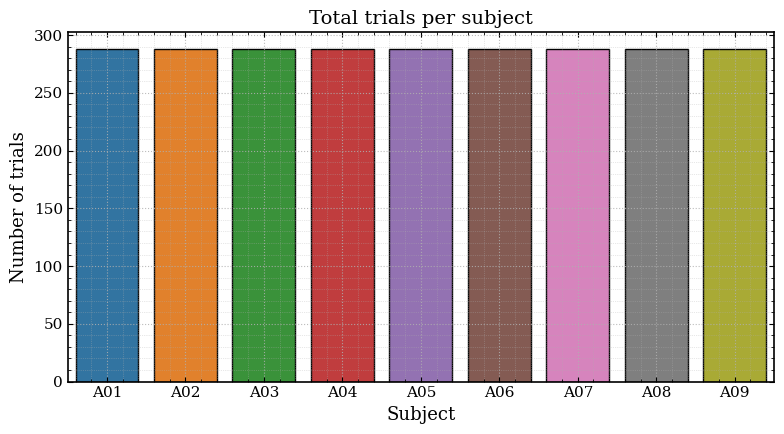

Saved: /kaggle/working/eeg_eda_outputs/fig_trials_per_subject.png


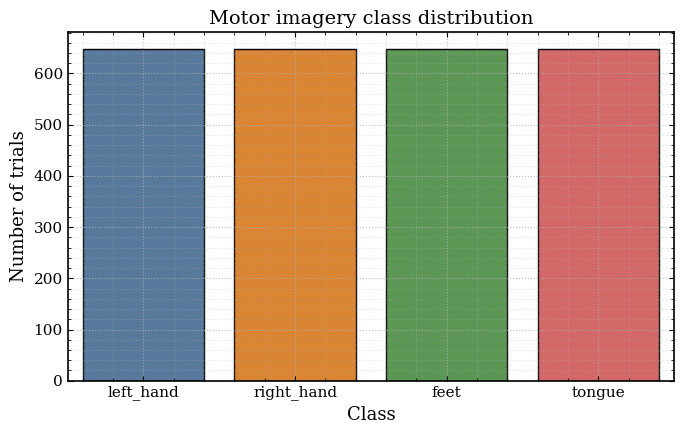

Saved: /kaggle/working/eeg_eda_outputs/fig_class_distribution.png


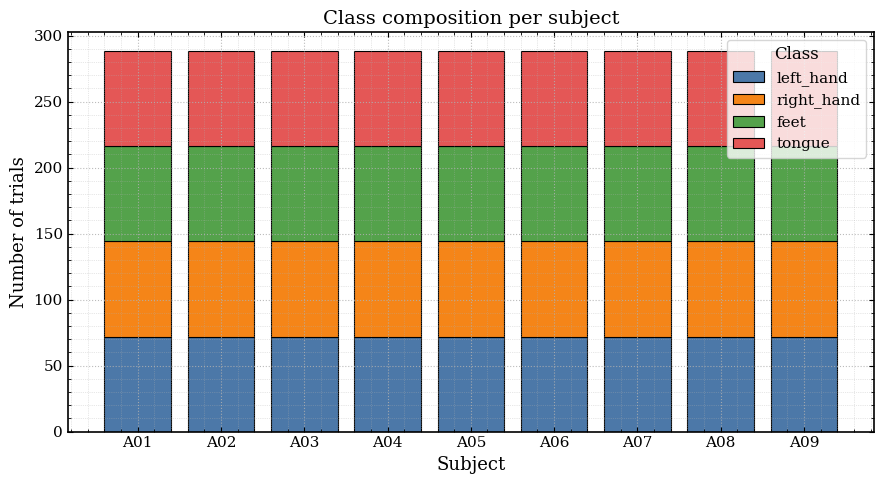

Saved: /kaggle/working/eeg_eda_outputs/fig_class_per_subject_stacked.png


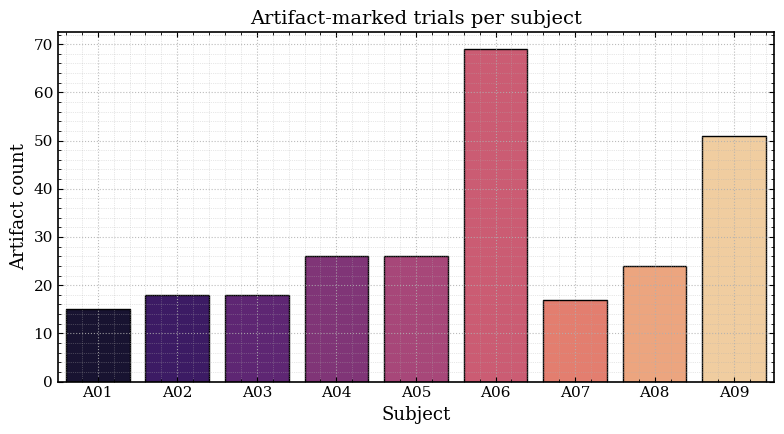

Saved: /kaggle/working/eeg_eda_outputs/fig_artifacts_per_subject.png


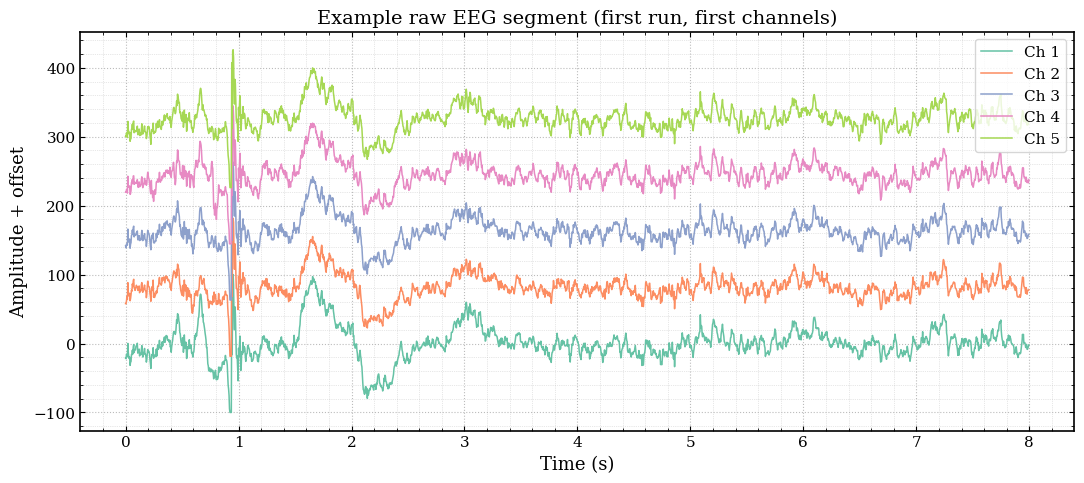

Saved: /kaggle/working/eeg_eda_outputs/fig_example_raw_eeg.png


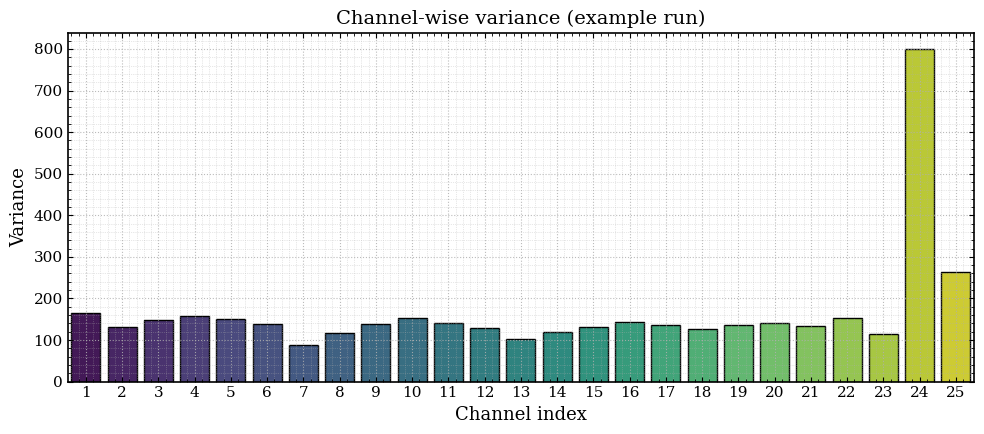

Saved: /kaggle/working/eeg_eda_outputs/fig_channel_variance_example_run.png


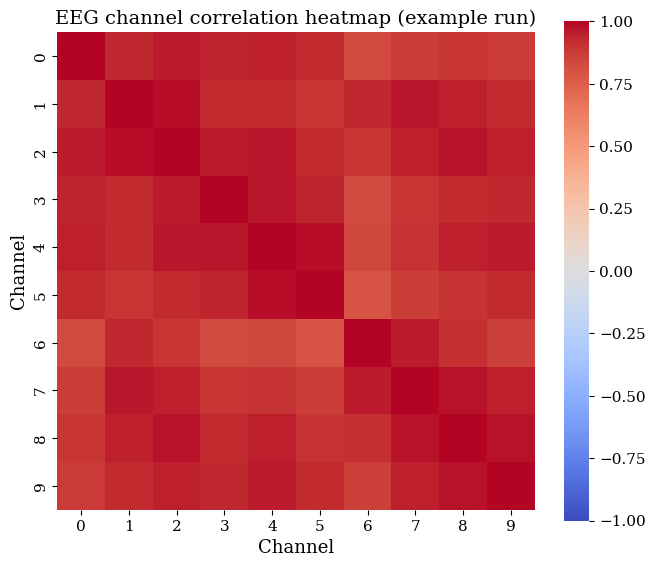

Saved: /kaggle/working/eeg_eda_outputs/fig_channel_correlation_heatmap.png

Saved files in output directory:
- class_summary_long.csv
- fig_artifacts_per_subject.png
- fig_channel_correlation_heatmap.png
- fig_channel_variance_example_run.png
- fig_class_distribution.png
- fig_class_per_subject_stacked.png
- fig_example_raw_eeg.png
- fig_trials_per_subject.png
- run_summary.csv
- subject_summary.csv


In [4]:
# ============================================
# EEG Motor Imagery EDA — Cell 3 (color version)
# Plots + save PNGs
# ============================================

# ---------- Color palette ----------
CLASS_COLORS = {
    "left_hand":  "#4C78A8",  # blue
    "right_hand": "#F58518",  # orange
    "feet":       "#54A24B",  # green
    "tongue":     "#E45756",  # red
}

SUBJECT_PALETTE = sns.color_palette("tab10", n_colors=len(subject_summary))
VAR_PALETTE = sns.color_palette("viridis", 25)

# Rebuild class totals safely
class_totals = (
    class_df.groupby(["class_id", "class_name"], as_index=False)["class_count"]
    .sum()
    .sort_values("class_id")
)

subject_class = (
    class_df.groupby(["subject", "class_name"], as_index=False)["class_count"]
    .sum()
)

# -------------------------------
# Plot 1: Trials per subject
# -------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=subject_summary,
    x="subject",
    y="total_trials",
    palette=SUBJECT_PALETTE,
    edgecolor="black",
    ax=ax
)
ax.set_title("Total trials per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Number of trials")
paper_axes(ax)
fig.tight_layout()

p1 = OUT_DIR / "fig_trials_per_subject.png"
fig.savefig(p1, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p1)

# -------------------------------
# Plot 2: Class distribution (dataset-wide)
# -------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    data=class_totals,
    x="class_name",
    y="class_count",
    palette=[CLASS_COLORS[c] for c in class_totals["class_name"]],
    edgecolor="black",
    ax=ax
)
ax.set_title("Motor imagery class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of trials")
paper_axes(ax)
fig.tight_layout()

p2 = OUT_DIR / "fig_class_distribution.png"
fig.savefig(p2, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p2)

# -------------------------------
# Plot 3: Class distribution per subject
# -------------------------------
pivot_sc = subject_class.pivot(index="subject", columns="class_name", values="class_count").fillna(0)
ordered_cols = [c for c in ["left_hand", "right_hand", "feet", "tongue"] if c in pivot_sc.columns]
pivot_sc = pivot_sc[ordered_cols]

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(pivot_sc))

for cls in ordered_cols:
    ax.bar(
        pivot_sc.index,
        pivot_sc[cls].values,
        bottom=bottom,
        label=cls,
        color=CLASS_COLORS[cls],
        edgecolor="black",
        linewidth=0.8
    )
    bottom += pivot_sc[cls].values

ax.set_title("Class composition per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Number of trials")
ax.legend(title="Class", frameon=True)
paper_axes(ax)
fig.tight_layout()

p3 = OUT_DIR / "fig_class_per_subject_stacked.png"
fig.savefig(p3, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p3)

# -------------------------------
# Plot 4: Artifact counts per subject
# -------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
artifact_palette = sns.color_palette("magma", n_colors=len(subject_summary))
sns.barplot(
    data=subject_summary,
    x="subject",
    y="total_artifacts",
    palette=artifact_palette,
    edgecolor="black",
    ax=ax
)
ax.set_title("Artifact-marked trials per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Artifact count")
paper_axes(ax)
fig.tight_layout()

p4 = OUT_DIR / "fig_artifacts_per_subject.png"
fig.savefig(p4, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p4)

# -------------------------------
# Plot 5: Example raw EEG segment from first run
# -------------------------------
example_run = all_runs[0]
X = np.array(getattr(example_run, "X"))
fs = float(getattr(example_run, "fs"))
n_plot_sec = 8
n_plot = min(int(fs * n_plot_sec), X.shape[0])

channels_to_plot = min(5, X.shape[1])
offset = np.nanstd(X[:n_plot, :channels_to_plot]) * 4.0

fig, ax = plt.subplots(figsize=(11, 5))
t = np.arange(n_plot) / fs
line_colors = sns.color_palette("Set2", n_colors=channels_to_plot)

for ch in range(channels_to_plot):
    ax.plot(
        t,
        X[:n_plot, ch] + ch * offset,
        linewidth=1.1,
        color=line_colors[ch],
        label=f"Ch {ch+1}"
    )

ax.set_title("Example raw EEG segment (first run, first channels)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude + offset")
ax.legend(loc="upper right", ncol=1, frameon=True)
paper_axes(ax)
fig.tight_layout()

p5 = OUT_DIR / "fig_example_raw_eeg.png"
fig.savefig(p5, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p5)

# -------------------------------
# Plot 6: Signal variance by channel (example run)
# -------------------------------
channel_var = np.var(X, axis=0)
var_df = pd.DataFrame({
    "channel_idx": np.arange(1, len(channel_var) + 1),
    "variance": channel_var
})

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(
    data=var_df,
    x="channel_idx",
    y="variance",
    palette=VAR_PALETTE[:len(var_df)],
    edgecolor="black",
    ax=ax
)
ax.set_title("Channel-wise variance (example run)")
ax.set_xlabel("Channel index")
ax.set_ylabel("Variance")
paper_axes(ax)
fig.tight_layout()

p6 = OUT_DIR / "fig_channel_variance_example_run.png"
fig.savefig(p6, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p6)

# -------------------------------
# Plot 7: Correlation heatmap (first 10 channels, example run)
# -------------------------------
n_corr_ch = min(10, X.shape[1])
corr = np.corrcoef(X[:min(3000, X.shape[0]), :n_corr_ch].T)

fig, ax = plt.subplots(figsize=(6.8, 5.8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar=True,
    annot=False,
    ax=ax
)
ax.set_title("EEG channel correlation heatmap (example run)")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
fig.tight_layout()

p7 = OUT_DIR / "fig_channel_correlation_heatmap.png"
fig.savefig(p7, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", p7)

# -------------------------------
# Final file list
# -------------------------------
print("\nSaved files in output directory:")
for f in sorted(OUT_DIR.iterdir()):
    print("-", f.name)